
## Seepage vs Δh Model Comparison (Centered $R^2$, Zero-Intercept)

We compare two origin-constrained models for **seepage** as a function of water-level difference **Δh**, using **centered $R^2$ only** and **no intercepts**:

- **Linear:** $S = K\,\Delta h$  
- **Offset–power:** $S = K\,\Delta h\,(\Delta h + \text{offset})^{b}$

We evaluate:
1. **Pooled fit (all events together).**
2. **Grouped fit (per event)** with AIC/BIC (summed across events) and centered $R^2$ (weighted by samples/event).




In [1]:
# --- Imports & configuration ---
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def r2_centered(y: np.ndarray, yhat: np.ndarray) -> float:
    """Centered R² = 1 − SSE/SST, where SST is around ȳ (fits are through origin)."""
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean())**2)
    return 1 - sse/sst if sst > 0 else np.nan

def aic_gaussian(sse: float, n: int, k: int) -> float:
    """AIC for LS under Gaussian errors: AIC = n·ln(SSE/n) + 2k (lower is better)."""
    return n * np.log(sse / n) + 2 * k

def bic_gaussian(sse: float, n: int, k: int) -> float:
    """BIC for LS under Gaussian errors: BIC = n·ln(SSE/n) + k·ln(n) (lower is better)."""
    return n * np.log(sse / n) + k * np.log(n)

# Models (through origin)
def model_linear(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Linear through origin: S = K · Δh."""
    K = params[0]
    return K * x

def model_power_offset(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Offset–power through origin: S = K · Δh · (Δh + offset)^b.
    Note: requires Δh + offset ≥ 0 for non-integer b; enforce upstream if needed."""
    K, offset, b = params
    return K * x * (x + offset)**b

def sse_linear(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the linear model."""
    return np.sum((y - model_linear(params, x))**2)

def sse_power_offset(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the offset–power model."""
    return np.sum((y - model_power_offset(params, x))**2)



## Load & clean data
- Parse `delta_h` and `seepage` as numeric.
- Drop NA; enforce `delta_h > 0` (for power terms).


In [2]:

data_path = Path("../data/processed/grouped.csv")  # adjust if needed
df = pd.read_csv(data_path)

df['delta_h'] = pd.to_numeric(df['delta_h'], errors='coerce')
df['seepage'] = pd.to_numeric(df['seepage'], errors='coerce')
df = df.dropna(subset=['delta_h','seepage'])

display(df[['delta_h','seepage','event']].head())
print(f"Closure days with data : {len(df)}")


,delta_h,seepage,event
0,0.728999,0.240583,0
1,0.803515,0.887796,0
2,0.906064,0.896792,0
3,0.966680,0.867753,0
4,1.036316,0.819474,0


Closure days with data : 399



## Pooled fits (includes all events)
Optimize parameters by minimizing SSE with bounds:
- Offset–power: `K ≥ 0`, `offset ≥ 0`, `b ≥ 0`
- Linear: `K ≥ 0`



In [3]:

x_all = df['delta_h'].to_numpy()
y_all = df['seepage'].to_numpy()
n_all = len(x_all)

# Linear
res_lin = minimize(sse_linear, x0=[1.0], args=(x_all, y_all), bounds=[(1e-12, None)])
K_lin = float(res_lin.x[0])
yhat_lin = model_linear([K_lin], x_all)
sse_lin = sse_linear([K_lin], x_all, y_all)
r2_lin = r2_centered(y_all, yhat_lin)
aic_lin = aic_gaussian(sse_lin, n_all, k=1)
bic_lin = bic_gaussian(sse_lin, n_all, k=1)

# Offset–power
res_pow = minimize(sse_power_offset, x0=[1.0, 0.1, 1.0], args=(x_all, y_all),
                   bounds=[(1e-12,None), (None,None), (None,None)])
K_pow, offset_pow, b_pow = map(float, res_pow.x)
yhat_pow = model_power_offset(res_pow.x, x_all)
sse_pow = sse_power_offset(res_pow.x, x_all, y_all)
r2_pow = r2_centered(y_all, yhat_pow)
aic_pow = aic_gaussian(sse_pow, n_all, k=3)
bic_pow = bic_gaussian(sse_pow, n_all, k=3)

pooled = pd.DataFrame({
    "model": ["K*Δh", "K*Δh*(Δh+offset)^b"],
    "K": [K_lin, K_pow],
    "offset": [np.nan, offset_pow],
    "b": [np.nan, b_pow],
    "R2_centered": [r2_lin, r2_pow],
    "SSE": [sse_lin, sse_pow],
    "AIC": [aic_lin, aic_pow],
    "BIC": [bic_lin, bic_pow],
    "n": [n_all, n_all],
})
display(pooled.round(2))

dAIC_pooled = pooled.loc[1, "AIC"] - pooled.loc[0, "AIC"]
dBIC_pooled = pooled.loc[1, "BIC"] - pooled.loc[0, "BIC"]
print(f"ΔAIC (pooled) = {dAIC_pooled:.3f}")
print(f"ΔBIC (pooled) = {dBIC_pooled:.3f}")


,model,K,offset,b,R2_centered,SSE,AIC,BIC,n
0,K*Δh,1.05,NaN,NaN,0.47,147.69,-394.56,-390.57,399
1,K*Δh*(Δh+offset)^b,0.99,-0.53,0.23,0.50,139.85,-412.32,-400.35,399


ΔAIC (pooled) = -17.764
ΔBIC (pooled) = -9.786



## Grouped fits (per event)
For each `event`, fit both models, compute centered $R^2$, SSE, AIC, BIC.  
Aggregate by:
- weighted centered $R^2$ (weights = per-event samples `n`),
- summed AIC/BIC across events.


In [4]:

rows = []
for event, d in df.groupby('event'):
    x = d['delta_h'].to_numpy()
    y = d['seepage'].to_numpy()
    n = len(x)
    if n < 6:  # avoid unstable fits on tiny samples
        continue

    # ----- Linear (through origin) -----
    # One free parameter (K). SSE minimized by bounded optimizer.
    rl = minimize(sse_linear, x0=[1.0], args=(x, y), bounds=[(1e-12, None)])
    Kl = float(rl.x[0])
    yhat_l = model_linear([Kl], x)
    ssel   = sse_linear([Kl], x, y)
    r2l    = r2_centered(y, yhat_l)
    aicl   = aic_gaussian(ssel, n, k=1)     # AIC with k=1 parameter
    bicl   = bic_gaussian(ssel, n, k=1)     # BIC with k=1 parameter

    # ----- Offset–power (through origin), negative offsets allowed -----
    # Three free parameters (K, offset, b).
    # Enforce real-valued power for fractional b by requiring (Δh + offset) ≥ 0.
    xmin  = float(np.min(x))
    eps   = 1e-12
    bounds_pow = [
        (1e-12, None),        # K ≥ 0
        (-xmin + eps, None),  # offset ≥ -min(Δh)  → base of power stays non-negative
        (0.0, None),          # b ≥ 0
    ]
    # Initial guess: moderate K, offset halfway toward allowable negative bound, near-linear b.
    x0_pow = [1.0, -0.5 * xmin, 1.0]

    # If model_power_offset does not guard negative bases, use np.maximum inside it.
    rp = minimize(sse_power_offset, x0=x0_pow, args=(x, y), bounds=bounds_pow)
    Kp, offp, bp = map(float, rp.x)
    yhat_p = model_power_offset(rp.x, x)
    ssep   = sse_power_offset(rp.x, x, y)
    r2p    = r2_centered(y, yhat_p)
    aicp   = aic_gaussian(ssep, n, k=3)     # AIC with k=3 parameters
    bicp   = bic_gaussian(ssep, n, k=3)     # BIC with k=3 parameters

    rows.append({
        "event": event, "n": n,
        "K_lin": Kl, "R2_lin": r2l, "SSE_lin": ssel, "AIC_lin": aicl, "BIC_lin": bicl,
        "K_pow": Kp, "offset": offp, "b": bp, "R2_pow": r2p, "SSE_pow": ssep, "AIC_pow": aicp, "BIC_pow": bicp
    })

grouped_fit = pd.DataFrame(rows).sort_values("event")
display(grouped_fit.head(10).round(2))

# Aggregate metrics across events:
weighted_r2_lin = np.average(grouped_fit["R2_lin"], weights=grouped_fit["n"])
weighted_r2_pow = np.average(grouped_fit["R2_pow"], weights=grouped_fit["n"])

AIC_lin_median = grouped_fit["AIC_lin"].median()
AIC_pow_median = grouped_fit["AIC_pow"].median()
BIC_lin_median = grouped_fit["BIC_lin"].median()
BIC_pow_median = grouped_fit["BIC_pow"].median()

# Negative ΔAIC/ΔBIC favors the offset–power model; positive favors linear.
dAIC_grouped = AIC_pow_median - AIC_lin_median
dBIC_grouped = BIC_pow_median - BIC_lin_median

print(f"Weighted R² — linear: {weighted_r2_lin:.4f}, offset–power: {weighted_r2_pow:.4f}")
print(f"ΣAIC linear={AIC_lin_median:.2f}, offset–power={AIC_pow_median:.2f}, ΔAIC={dAIC_grouped:.2f}")
print(f"ΣBIC linear={BIC_lin_median:.2f}, offset–power={BIC_pow_median:.2f}, ΔBIC={dBIC_grouped:.2f}")
grouped_fit.shape

,event,n,K_lin,R2_lin,SSE_lin,AIC_lin,BIC_lin,K_pow,offset,b,R2_pow,SSE_pow,AIC_pow,BIC_pow
0,0,28,0.79,0.39,3.77,-54.17,-52.84,0.79,-0.47,0.00,0.39,3.77,-50.17,-46.17
1,1,25,0.95,0.64,1.27,-72.53,-71.31,1.00,-1.11,0.10,0.71,1.01,-74.21,-70.55
2,2,28,1.02,0.72,3.69,-54.78,-53.45,0.00,12.15,2.36,0.75,3.30,-53.89,-49.90
3,3,23,0.90,0.05,2.72,-47.13,-46.00,0.90,-0.04,0.00,0.05,2.72,-43.13,-39.72
4,4,21,1.09,0.78,3.11,-38.14,-37.09,1.11,-0.95,0.14,0.84,2.21,-41.28,-38.15
5,5,17,1.20,0.41,7.64,-11.59,-10.76,1.27,-0.89,0.17,0.46,7.07,-8.91,-6.41
6,6,18,0.90,0.79,1.50,-42.69,-41.80,0.90,-0.77,0.10,0.83,1.19,-42.91,-40.24
7,7,17,0.54,0.28,0.40,-61.84,-61.00,0.58,-0.78,0.04,0.29,0.39,-58.21,-55.71
8,8,21,0.74,0.52,1.48,-53.70,-52.66,0.77,-0.96,0.38,0.64,1.10,-55.97,-52.84
9,9,22,1.66,0.83,1.70,-54.27,-53.18,1.66,0.29,0.00,0.83,1.70,-50.27,-47.00


Weighted R² — linear: 0.5494, offset–power: 0.6142
ΣAIC linear=-29.60, offset–power=-29.41, ΔAIC=0.19
ΣBIC linear=-29.11, offset–power=-28.81, ΔBIC=0.30


(23, 14)

Good question — let’s interpret what those AIC and BIC outputs mean in your pooled fit context.

---

## 1. What the criteria are

* **AIC (Akaike Information Criterion)**
  $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  where $n$ is sample size, SSE the sum of squared residuals, and $k$ the number of free parameters.
  • Lower AIC means better expected **out-of-sample predictive accuracy** (minimizes KL divergence).
  • It penalizes complexity with $2k$.

* **BIC (Bayesian Information Criterion)**
  $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$.
  • Lower BIC means stronger evidence for the model under a Bayesian marginal likelihood approximation.
  • It penalizes complexity more heavily than AIC (because $k \ln n \gg 2k$ when $n$ is large).

---

## 2. Assumptions

Both derive from the same likelihood framework:

* Residuals are **independent, identically distributed, Gaussian** with constant variance.
* Models are fit by **maximum likelihood** (your least-squares regression satisfies this).
* AIC’s information-theoretic foundation is predictive (best for model comparison, not “truth”).
* BIC’s Bayesian foundation is evidence-based (tries to approximate posterior probability of models).
* Absolute AIC/BIC values are meaningless — only **differences (ΔAIC, ΔBIC)** matter.

---

## 3. How to interpret your numbers

* You print:

  ```
  ΔAIC (pooled) = {dAIC_pooled}
  ΔBIC (pooled) = {dBIC_pooled}
  ```

  where Δ = (offset–power) − (linear).

* **If ΔAIC < 0:** the offset–power model is preferred (strongly if Δ ≤ −10).
  **If ΔAIC > 0:** the linear model is preferred.
  Rules of thumb for ΔAIC:

  * 0–2: negligible support
  * 4–7: some support
  * ≥10: strong/decisive support

* **If ΔBIC < 0:** offset–power is preferred; **ΔBIC > 0:** linear is preferred.
  BIC is harsher on complexity, so if you see ΔAIC slightly negative (favoring offset–power) but ΔBIC positive (favoring linear), it means:

  > The more flexible model fits a bit better, but the improvement isn’t big enough to justify two extra parameters given your n.

---

## 4. Practical takeaway in your case

* Look at the **sign and magnitude** of ΔAIC and ΔBIC.
* If ΔAIC is small (say −2) and ΔBIC is positive, then the offset–power adds complexity without convincing gains → stick with linear.
* If ΔAIC is very negative (≤−10), then the extra parameters clearly buy predictive accuracy, even if BIC is still skeptical.

---

👉 Want me to show you a simple rules-of-thumb table (ΔAIC and ΔBIC ranges and what they mean) that you can drop into your repo’s README as interpretation guidance?



### Best-fit exponent $b$ and offset (per-event)
Weighted by sample count per event, plus robust summaries.


In [5]:
from scipy.stats import normaltest
import numpy as np
import pandas as pd

# --- helpers ---
def weighted_quantile(x: np.ndarray, w: np.ndarray, q: float) -> float:
    """Weighted quantile in [0,1]; float-casts; ignores non-finite; allows zero/uneven weights."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w >= 0)
    if not np.any(m): return np.nan
    x, w = x[m], w[m]
    s = w.sum()
    if s <= 0: return np.nan
    o = np.argsort(x, kind="mergesort")
    x, w = x[o], w[o]
    cw = np.cumsum(w, dtype=float) / s
    return np.interp(q, cw, x)

def weighted_iqr(x: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    """Weighted IQR (q25, q75)."""
    return weighted_quantile(x, w, 0.25), weighted_quantile(x, w, 0.75)

def iqr_unweighted(x: np.ndarray) -> tuple[float, float]:
    """Unweighted IQR (q25, q75)."""
    x = np.asarray(x, dtype=float)
    return tuple(np.quantile(x, [0.25, 0.75]))

def normality_p_unweighted(x: np.ndarray) -> float:
    """D’Agostino–Pearson normality p-value (H0: normal)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8: return np.nan
    _, p = normaltest(x)
    return float(p)

def fmt_iqr(q25: float, q75: float) -> str:
    return f"{q25:.3g} – {q75:.3g}"

def summarize(vals: np.ndarray, wts: np.ndarray):
    """Weighted/unweighted medians & IQRs + unweighted normality p."""
    med_w = weighted_quantile(vals, wts, 0.50)
    q25_w, q75_w = weighted_iqr(vals, wts)
    med_u = float(np.median(vals))
    q25_u, q75_u = iqr_unweighted(vals)
    p = normality_p_unweighted(vals)
    note = ("reject normality; prefer medians/IQR" if (np.isfinite(p) and p < 0.05)
            else "no evidence against normality")
    return med_w, fmt_iqr(q25_w, q75_w), med_u, fmt_iqr(q25_u, q75_u), p, note

# --- data ---
w = grouped_fit["n"].to_numpy()
series = {
    "b":            grouped_fit["b"].to_numpy().round(3),
    "offset":       grouped_fit["offset"].to_numpy(),
    "R² (linear)":  grouped_fit["R2_lin"].to_numpy().round(3),
    "R² (offset–power)": grouped_fit["R2_pow"].to_numpy().round(3),
}

# --- build summary table with consistent columns ---
rows = {}
for name, vals in series.items():
    med_w, iqr_w, med_u, iqr_u, p, note = summarize(vals, w)
    rows[name] = {
        "median (unweighted)":          med_u,
        "IQR q25–q75 (unweighted)":     iqr_u,
        "median (weighted)":            med_w,
        "IQR q25–q75 (weighted)":       iqr_w,        
         # "normality p (unweighted)":     p,
    }

summary_consistent = pd.DataFrame.from_dict(rows, orient="index")
display(summary_consistent.T.round(4))


,b,offset,R² (linear),R² (offset–power)
median (unweighted),0.104,-0.33766,0.564,0.704
IQR q25–q75 (unweighted),0 – 1.42,-0.92 – 1.37,0.421 – 0.698,0.443 – 0.816
median (weighted),0.1028,-0.476219,0.567429,0.686818
IQR q25–q75 (weighted),0 – 1.02,-0.945 – 0.857,0.39 – 0.706,0.392 – 0.801



## visualization: pooled data with fitted curves


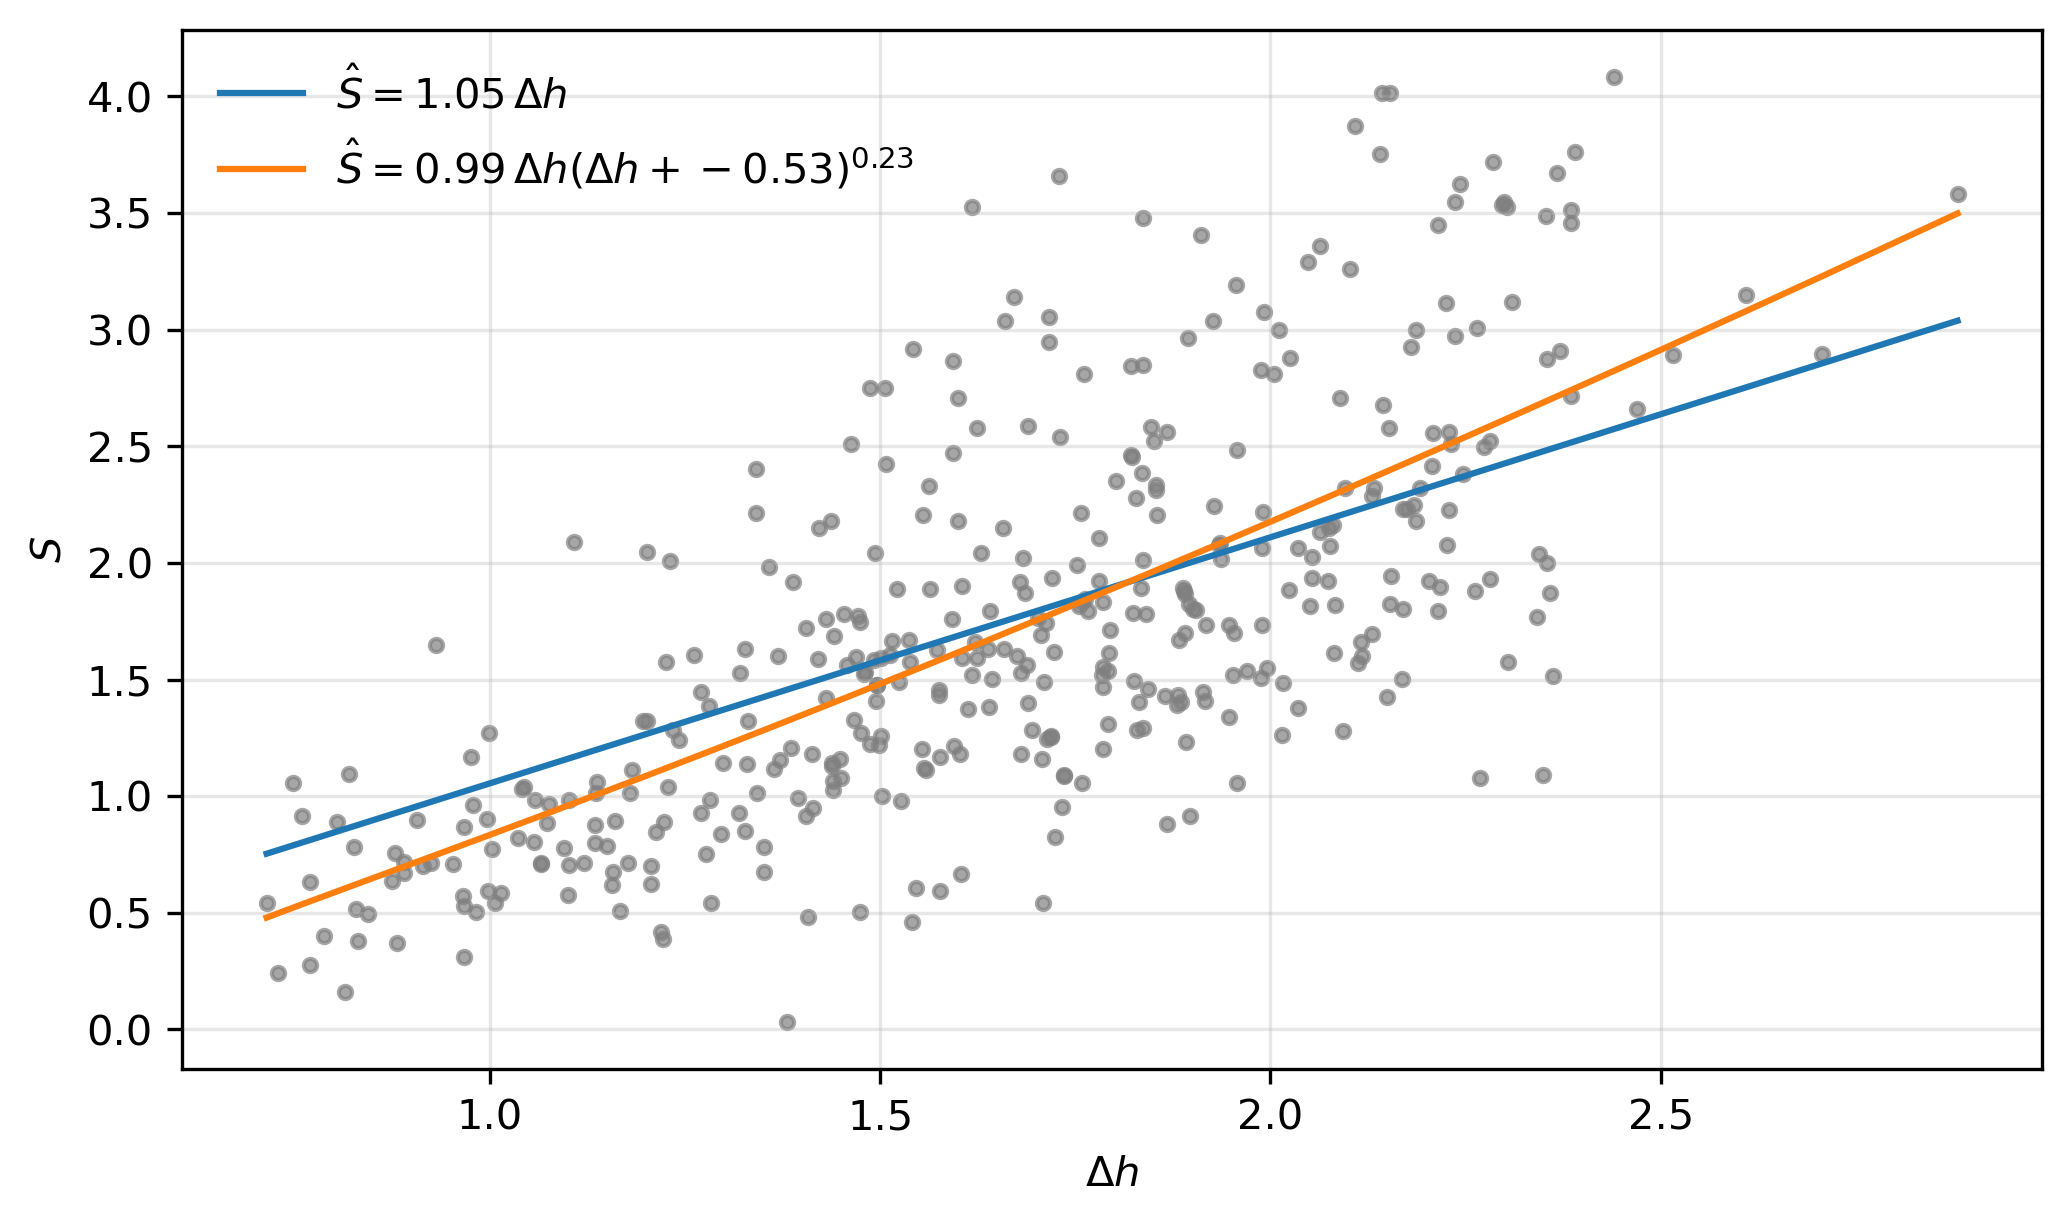

In [6]:

fig, ax = plt.subplots()
ax.scatter(x_all, y_all, s=10, c="0.5", alpha=0.7, label="")

order = np.argsort(x_all)
xs = x_all[order]
ax.plot(xs, model_linear([K_lin], xs), label=fr"$\hat S = {K_lin:.2f}\,\Delta h$")
ax.plot(xs, model_power_offset([K_pow, offset_pow, b_pow], xs),
        label=fr"$\hat S = {K_pow:.2f}\,\Delta h(\Delta h+{offset_pow:.2f})^{{{b_pow:.2f}}}$")

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.legend(frameon=False)
plt.show()
